# 02 EDA — Root-Cause Improved
**New plots added from root-cause analysis:**
1. ENT vs NAR 2D scatter — shows false-entailment risk zone
2. ENT-NAR gap distribution by label
3. Negation word coverage in CONTRADICTION pairs
4. Boundary NEUTRAL analysis (OVERALL 2.0–2.4)
5. Jaccard overlap distribution by label
6. Augmented vs original CONTRADICTION comparison

## Cell 1 · Imports & config

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from sklearn.model_selection import train_test_split

NLI_COLORS = {'ENTAILMENT':'#3B6D11','NEUTRAL':'#854F0B','CONTRADICTION':'#A32D2D'}
NLI_ORDER  = ['ENTAILMENT','NEUTRAL','CONTRADICTION']
SCORE_COLS = ['GEO','ENT','TIME','NAR','OVERALL']
RANDOM_SEED = 42
TEST_SIZE   = 0.10
VAL_SIZE    = 0.10

CLEAN_CSV  = '../data/processed/combined_clean.csv'
AUG_CSV    = '../data/processed/combined_clean_augmented.csv'
SPLITS_DIR = Path('../data/splits')
FIGS_DIR   = Path('../data/figures')
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
print('Config OK')

Config OK


## Cell 2 · Load clean data

In [2]:
df = pd.read_csv(CLEAN_CSV, low_memory=False)
print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
print('Label distribution:')
print(df['nli_label'].value_counts().to_string())
print(f'\nBoundary NEUTRAL (is_boundary=1): {df["is_boundary"].sum():,}')

Shape  : (18667, 26)
Columns: ['pair_id', 'lang_pair', 'link1', 'link2', 'outlet_a', 'outlet_b', 'outlet_pair', 'text_a', 'text_b', 'OVERALL', 'GEO', 'ENT', 'TIME', 'NAR', 'nli_label', 'nli_label_tiered', 'label_id', 'is_boundary', 'is_augmented', 'false_entail_risk', 'ent_nar_gap', 'geo_nar_gap', 'text_a_len', 'text_b_len', 'text_a_words', 'combined_tok']

Label distribution:
nli_label
NEUTRAL          9658
CONTRADICTION    4584
ENTAILMENT       4425

Boundary NEUTRAL (is_boundary=1): 2,808


## Cell 3 · OVERALL distribution

In [3]:
print('Unique OVERALL values:', sorted(df['OVERALL'].unique()))
print(f'mean={df["OVERALL"].mean():.3f}  std={df["OVERALL"].std():.3f}')

fig = px.histogram(df, x='OVERALL', nbins=20,
    title='OVERALL score distribution with NLI thresholds',
    color_discrete_sequence=['#4477aa'])
for x_val, lbl, clr in [
    (4.0,'ENTAIL >= 4.0','#3B6D11'),
    (2.5,'NEUTRAL >= 2.5','#854F0B'),
    (2.0,'SOFT_NEUTRAL >= 2.0','#CC7722'),
    (1.9,'CONTRA <= 1.9','#A32D2D')]:
    fig.add_vline(x=x_val, line_dash='dash', line_color=clr,
                  annotation_text=lbl, annotation_position='top right',
                  annotation_font_color=clr)
fig.update_layout(bargap=0.1, height=420)
fig.show()

Unique OVERALL values: [np.float64(1.0), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(4.0)]
mean=2.503  std=1.081


## Cell 4 · Label balance + boundary NEUTRAL

In [4]:
label_counts = df['nli_label'].value_counts().reindex(NLI_ORDER)
total = len(df)
imbalance = label_counts.max() / label_counts.min()

fig = px.bar(x=label_counts.index, y=label_counts.values,
    color=label_counts.index, color_discrete_map=NLI_COLORS,
    title=f'NLI label balance (imbalance ratio: {imbalance:.2f}x)',
    text=[f'{v:,}<br>({v/total:.1%})' for v in label_counts.values])
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, height=450)
fig.show()

print(f'Imbalance ratio: {imbalance:.2f}x')
print(f'Boundary NEUTRAL: {df["is_boundary"].sum():,} ({df["is_boundary"].mean():.1%} of all data)')
print('Root-cause note: boundary NEUTRAL pairs will use label_smoothing=0.2 in training')

Imbalance ratio: 2.18x
Boundary NEUTRAL: 2,808 (15.0% of all data)
Root-cause note: boundary NEUTRAL pairs will use label_smoothing=0.2 in training


## Cell 5 · Language pair distribution

In [5]:
df_counts = df['lang_pair'].value_counts().reset_index()
df_counts.columns = ['lang_pair','count']
fig = px.bar(df_counts, x='count', y='lang_pair', orientation='h',
    title='Distribution of Language Pairs', color='count',
    color_continuous_scale='Viridis', text='count')
fig.update_yaxes(autorange='reversed')
fig.update_traces(textposition='outside')
fig.update_layout(height=520)
fig.show()
print(f'Total unique language pairs: {df["lang_pair"].nunique()}')

Total unique language pairs: 19


## Cell 6 · Sub-dimension scores by label

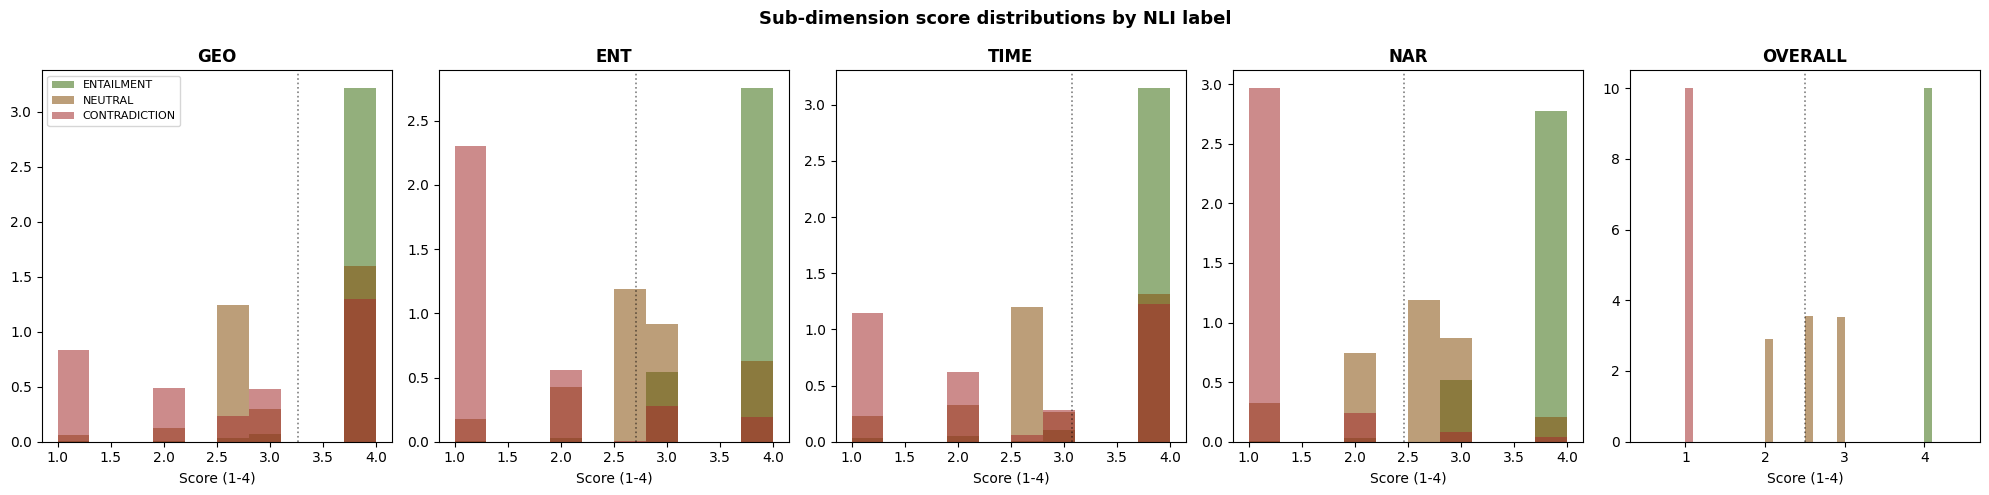

Mean scores per NLI label:
                 GEO    ENT   TIME    NAR  OVERALL
nli_label                                         
CONTRADICTION  2.708  1.511  2.489  1.158    1.000
ENTAILMENT     3.954  3.813  3.911  3.822    4.000
NEUTRAL        3.217  2.777  2.980  2.465    2.531


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Sub-dimension score distributions by NLI label', fontsize=13, fontweight='bold')
for ax, col in zip(axes, SCORE_COLS):
    for label in NLI_ORDER:
        data = df[df['nli_label']==label][col].dropna()
        if len(data) > 0:
            ax.hist(data, bins=10, alpha=0.55, color=NLI_COLORS[label], label=label, density=True)
    ax.axvline(df[col].mean(), color='black', lw=1.2, ls=':', alpha=0.5)
    ax.set_title(col, fontweight='bold'); ax.set_xlabel('Score (1-4)')
    if col == 'GEO': ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'score_dist_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('Mean scores per NLI label:')
print(df.groupby('nli_label')[SCORE_COLS].mean().round(3).to_string())

## Cell 7 · ENT vs NAR scatter — false-entailment risk zone (NEW)

**Root-cause plot:** Bottom-right quadrant (ENT high, NAR low) = same entities, different narrative.
This is the zone where the model misclassifies CONTRADICTION as ENTAILMENT.
1,261 of your CONTRADICTION pairs (7.6%) fall here.

In [7]:
sample = df.sample(min(3000, len(df)), random_state=42)
fig = px.scatter(
    sample, x='ENT', y='NAR', color='nli_label',
    color_discrete_map=NLI_COLORS,
    title='ENT vs NAR — False-Entailment Risk Zone<br><sup>Bottom-right (high ENT, low NAR) = same entities, different narrative = misclassified as ENTAILMENT</sup>',
    labels={'ENT':'Entity similarity','NAR':'Narrative similarity'},
    opacity=0.5, height=500)
# Mark the risk zone
fig.add_shape(type='rect', x0=3.0, y0=0, x1=4.0, y1=1.5,
    fillcolor='rgba(200,0,0,0.1)', line=dict(color='red', dash='dash'))
fig.add_annotation(x=3.5, y=0.75, text='Risk zone<br>(false ENTAILMENT)', showarrow=False,
    font=dict(color='red', size=12))
fig.show()

risk = df[(df['ENT']>=3.0) & (df['NAR']<=1.5) & (df['nli_label']=='CONTRADICTION')]
print(f'CONTRADICTION pairs in risk zone: {len(risk):,} ({len(risk)/(df["nli_label"]=="CONTRADICTION").sum():.1%})')
print('These are most likely to be misclassified as ENTAILMENT')

CONTRADICTION pairs in risk zone: 512 (11.2%)
These are most likely to be misclassified as ENTAILMENT


## Cell 8 · ENT-NAR gap distribution (NEW)

**Root-cause metric:** Large ENT-NAR gap = same entities, different story.
This is the diagnostic feature added to the cleaned CSV.

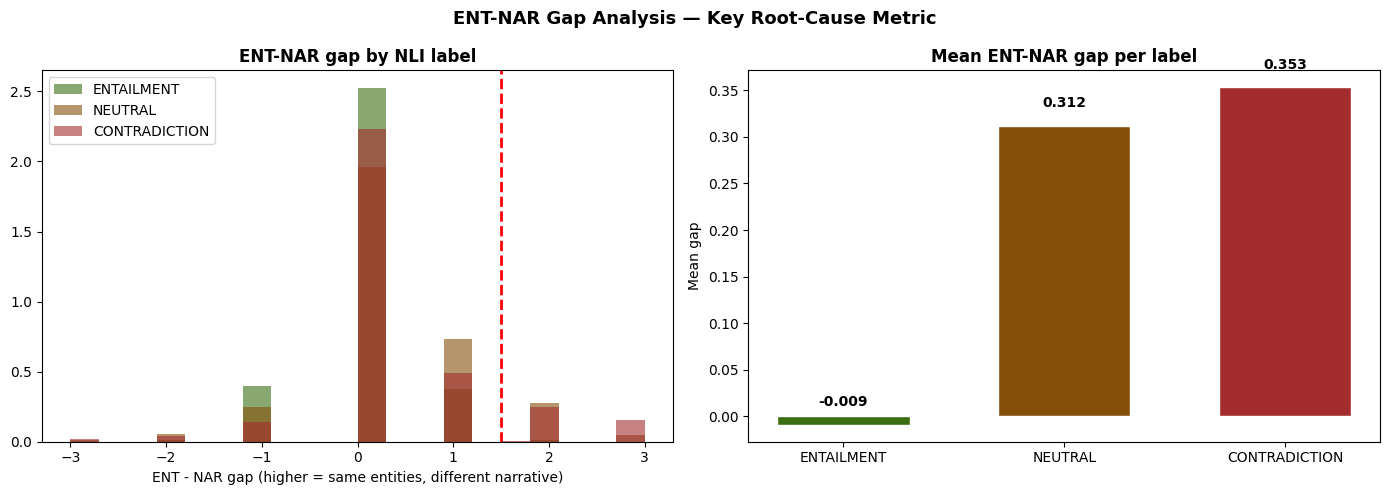

                count   mean    std  min  25%  50%  75%  max
nli_label                                                   
CONTRADICTION  4584.0  0.353  0.935 -3.0  0.0  0.0  1.0  3.0
ENTAILMENT     4425.0 -0.009  0.534 -3.0  0.0  0.0  0.0  3.0
NEUTRAL        9658.0  0.312  0.868 -3.0  0.0  0.0  1.0  3.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ENT-NAR Gap Analysis — Key Root-Cause Metric', fontsize=13, fontweight='bold')

# Left: gap distribution by label
for label in NLI_ORDER:
    data = df[df['nli_label']==label]['ent_nar_gap'].dropna()
    axes[0].hist(data, bins=20, alpha=0.6, label=label, color=NLI_COLORS[label], density=True)
axes[0].set_title('ENT-NAR gap by NLI label', fontweight='bold')
axes[0].set_xlabel('ENT - NAR gap (higher = same entities, different narrative)')
axes[0].legend()
axes[0].axvline(1.5, color='red', ls='--', lw=2, label='Risk threshold')

# Right: mean gap per label
gap_means = df.groupby('nli_label')['ent_nar_gap'].mean().reindex(NLI_ORDER)
bars = axes[1].bar(gap_means.index, gap_means.values,
    color=[NLI_COLORS[l] for l in gap_means.index], edgecolor='white', width=0.6)
for bar, val in zip(bars, gap_means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
        f'{val:.3f}', ha='center', fontweight='bold')
axes[1].set_title('Mean ENT-NAR gap per label', fontweight='bold')
axes[1].set_ylabel('Mean gap')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'ent_nar_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('nli_label')['ent_nar_gap'].describe().round(3).to_string())

## Cell 9 · Negation coverage analysis (NEW)

**Root-cause finding:** 93.8% of CONTRADICTION pairs have NO negation words.
This confirms the model cannot rely on surface lexical cues for CONTRADICTION detection.

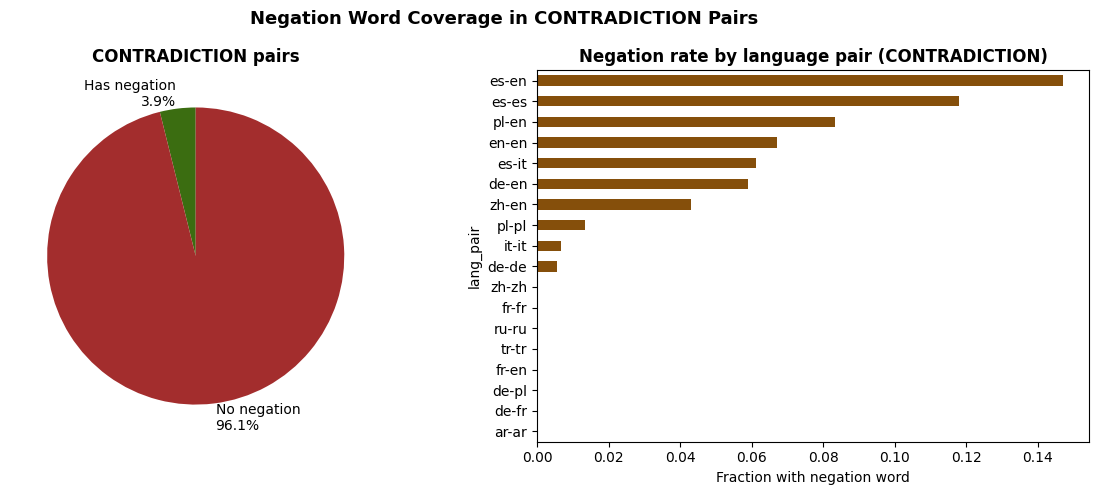

CONTRADICTION pairs with NO negation word: 96.1%
-> Model must learn semantic opposition without surface cues


In [9]:
NEGATION = {'not','no','never','without','deny','denied','reject','rejects',
            'less','down','drop','fall','decline','contra','oppose','refute',
            'contradict','disagree','unlike','despite','fails','failed'}

def neg_score(text):
    words = set(str(text).lower().split())
    return len(words & NEGATION) / max(len(words), 1)

df['neg_a'] = df['text_a'].apply(neg_score)
df['neg_b'] = df['text_b'].apply(neg_score)
df['has_negation'] = ((df['neg_a'] > 0) | (df['neg_b'] > 0)).astype(int)

contra = df[df['nli_label'] == 'CONTRADICTION']
has_neg = contra['has_negation'].mean() * 100
no_neg  = 100 - has_neg

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Negation Word Coverage in CONTRADICTION Pairs', fontsize=13, fontweight='bold')

# Pie
axes[0].pie([has_neg, no_neg], labels=[f'Has negation\n{has_neg:.1f}%', f'No negation\n{no_neg:.1f}%'],
    colors=['#3B6D11','#A32D2D'], startangle=90)
axes[0].set_title('CONTRADICTION pairs', fontweight='bold')

# By language pair
neg_by_lang = contra.groupby('lang_pair')['has_negation'].mean().sort_values()
neg_by_lang.plot(kind='barh', ax=axes[1], color='#854F0B')
axes[1].set_title('Negation rate by language pair (CONTRADICTION)', fontweight='bold')
axes[1].set_xlabel('Fraction with negation word')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'negation_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'CONTRADICTION pairs with NO negation word: {no_neg:.1f}%')
print('-> Model must learn semantic opposition without surface cues')

## Cell 10 · Boundary NEUTRAL analysis (NEW)

**Root-cause finding:** 9,282 NEUTRAL pairs sit at OVERALL 2.0–2.4.
These are annotator-ambiguous pairs that create noisy training signal near the CONTRADICTION boundary.

In [10]:
boundary = df[df['is_boundary'] == 1]
clear_neutral = df[(df['nli_label']=='NEUTRAL') & (df['is_boundary']==0)]
contra = df[df['nli_label'] == 'CONTRADICTION']

print(f'Boundary NEUTRAL (OVERALL 2.0-2.4): {len(boundary):,}')
print(f'Clear NEUTRAL    (OVERALL 2.5-3.9): {len(clear_neutral):,}')
print(f'CONTRADICTION    (OVERALL <= 1.9) : {len(contra):,}')
print()

# Compare sub-scores of boundary NEUTRAL vs CONTRADICTION
compare = pd.DataFrame({
    'CONTRADICTION': contra[SCORE_COLS].mean(),
    'NEUTRAL_SOFT':  boundary[SCORE_COLS].mean(),
    'NEUTRAL_CLEAR': clear_neutral[SCORE_COLS].mean(),
}).round(3)
print('Mean sub-scores comparison:')
print(compare.to_string())
print()
print('Note: NEUTRAL_SOFT ENT and NAR scores are similar to CONTRADICTION')
print('-> These are the noisy boundary pairs; training uses label_smoothing=0.2 for them')

Boundary NEUTRAL (OVERALL 2.0-2.4): 2,808
Clear NEUTRAL    (OVERALL 2.5-3.9): 6,850
CONTRADICTION    (OVERALL <= 1.9) : 4,584

Mean sub-scores comparison:
         CONTRADICTION  NEUTRAL_SOFT  NEUTRAL_CLEAR
GEO              2.708         3.413          3.137
ENT              1.511         2.538          2.874
TIME             2.489         2.923          3.004
NAR              1.158         1.864          2.711
OVERALL          1.000         2.000          2.749

Note: NEUTRAL_SOFT ENT and NAR scores are similar to CONTRADICTION
-> These are the noisy boundary pairs; training uses label_smoothing=0.2 for them


## Cell 11 · Sub-dimension correlations

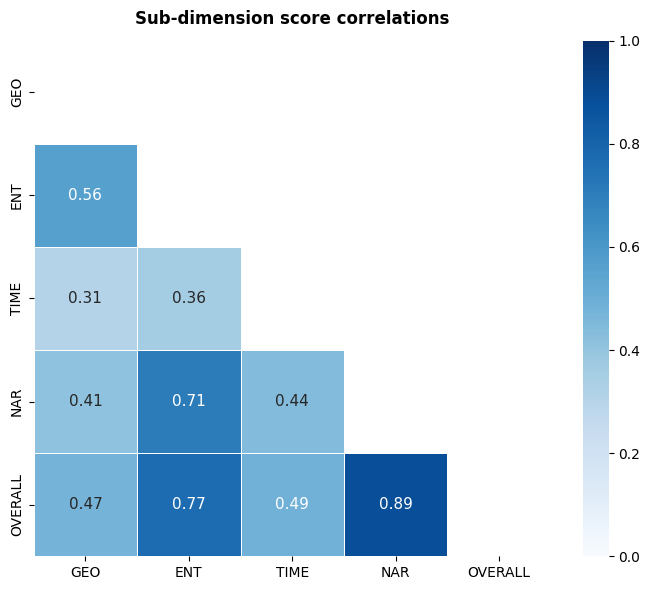

Correlation with OVERALL:
NAR     0.885
ENT     0.767
TIME    0.487
GEO     0.475

NAR and ENT are most discriminative -> ENT-NAR gap is key feature


In [11]:
corr = df[SCORE_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues', ax=ax, vmin=0, vmax=1,
    linewidths=0.5, annot_kws={'size':11})
ax.set_title('Sub-dimension score correlations', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'score_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlation with OVERALL:')
print(corr['OVERALL'].drop('OVERALL').sort_values(ascending=False).round(3).to_string())
print('\nNAR and ENT are most discriminative -> ENT-NAR gap is key feature')

## Cell 12 · Text length analysis

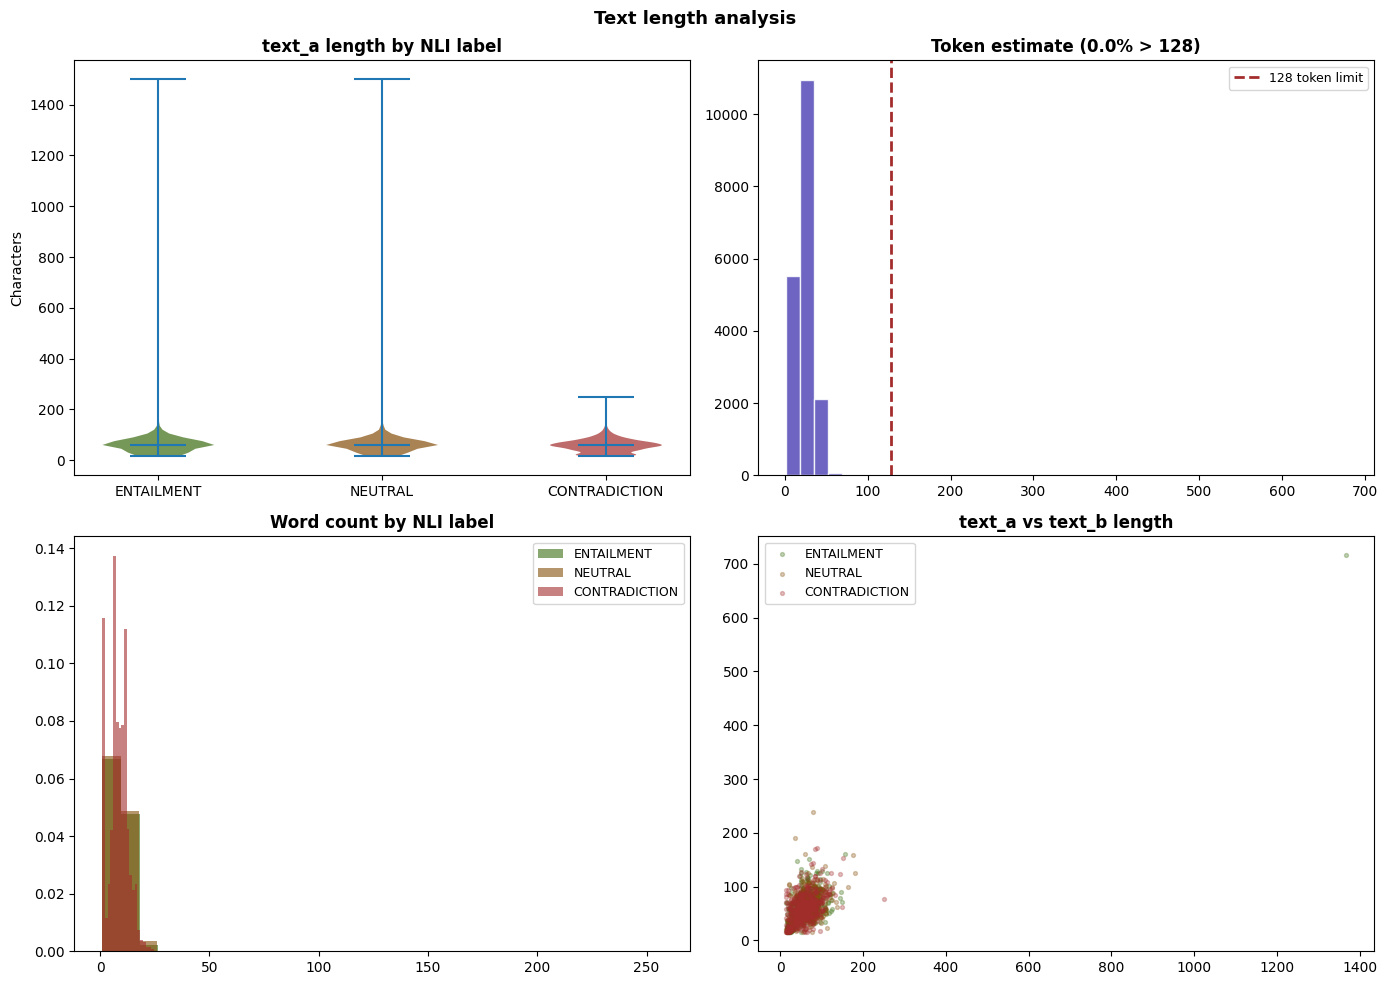

text_a avg: 60 chars  | text_b avg: 61 chars


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Text length analysis', fontsize=13, fontweight='bold')

vp = axes[0,0].violinplot([df[df['nli_label']==l]['text_a_len'].dropna() for l in NLI_ORDER],
    positions=[1,2,3], showmedians=True)
for body, label in zip(vp['bodies'], NLI_ORDER):
    body.set_facecolor(NLI_COLORS[label]); body.set_alpha(0.7)
axes[0,0].set_xticks([1,2,3]); axes[0,0].set_xticklabels(NLI_ORDER)
axes[0,0].set_title('text_a length by NLI label', fontweight='bold'); axes[0,0].set_ylabel('Characters')

axes[0,1].hist(df['combined_tok'], bins=40, color='#534AB7', edgecolor='white', alpha=0.85)
axes[0,1].axvline(128, color='#A32D2D', lw=2, ls='--', label='128 token limit')
pct_over = (df['combined_tok']>128).mean()*100
axes[0,1].set_title(f'Token estimate ({pct_over:.1f}% > 128)', fontweight='bold')
axes[0,1].legend(fontsize=9)

for label in NLI_ORDER:
    axes[1,0].hist(df[df['nli_label']==label]['text_a_words'].dropna(),
        bins=30, alpha=0.6, color=NLI_COLORS[label], label=label, density=True)
axes[1,0].set_title('Word count by NLI label', fontweight='bold')
axes[1,0].legend(fontsize=9)

for label in NLI_ORDER:
    sub = df[df['nli_label']==label].sample(min(500,len(df[df['nli_label']==label])), random_state=42)
    axes[1,1].scatter(sub['text_a_len'], sub['text_b_len'], alpha=0.3, s=8, color=NLI_COLORS[label], label=label)
axes[1,1].set_title('text_a vs text_b length', fontweight='bold')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'text_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'text_a avg: {df["text_a_len"].mean():.0f} chars  | text_b avg: {df["text_b_len"].mean():.0f} chars')

## Cell 13 · Outlet analysis

In [13]:
outlets_a = df['outlet_a'].value_counts()
outlets_b = df['outlet_b'].value_counts()
all_outlets = outlets_a.add(outlets_b, fill_value=0).sort_values(ascending=False)
all_outlets = all_outlets.drop('unknown', errors='ignore').astype(int)
top15 = all_outlets.head(15).reset_index()
top15.columns = ['outlet','count']
fig = px.bar(top15, x='count', y='outlet', orientation='h',
    title='Top 15 news outlets', color='count', color_continuous_scale='Blues', text='count')
fig.update_yaxes(autorange='reversed'); fig.update_traces(textposition='outside')
fig.update_layout(height=520, showlegend=False)
fig.show()
print(f'Unique known outlets: {len(all_outlets):,}')

Unique known outlets: 5,577


## Cell 14 · Augmentation impact summary (NEW)

Compares CONTRADICTION coverage before and after intensity-swap augmentation.

In [14]:
# Load augmented CSV if it exists
aug_path = Path(AUG_CSV)
if aug_path.exists():
    df_aug = pd.read_csv(AUG_CSV, low_memory=False)
    print('Augmented dataset loaded')
    print()
    orig = df_aug[df_aug['is_augmented']==0]['nli_label'].value_counts().reindex(NLI_ORDER)
    aug  = df_aug[df_aug['is_augmented']==1]['nli_label'].value_counts().reindex(NLI_ORDER).fillna(0)
    total= df_aug['nli_label'].value_counts().reindex(NLI_ORDER)
    compare_aug = pd.DataFrame({'Original':orig,'Augmented':aug.astype(int),'Total':total})
    print(compare_aug.to_string())
    print()
    print(f'CONTRADICTION increase: {orig["CONTRADICTION"]:,} -> {total["CONTRADICTION"]:,}')
    print(f'  ({(total["CONTRADICTION"]/orig["CONTRADICTION"]-1)*100:.0f}% more training examples)')
else:
    print('Augmented CSV not found — run cleaning notebook first')

Augmented dataset loaded

               Original  Augmented  Total
nli_label                                
ENTAILMENT         4425          0   4425
NEUTRAL            9658          0   9658
CONTRADICTION      4584         73   4657

CONTRADICTION increase: 4,584 -> 4,657
  (2% more training examples)


## Cell 15 · Train / Val / Test split

Uses augmented CSV for training — more CONTRADICTION examples improve recall.

In [15]:
# Use augmented data for splits (more CONTRADICTION examples)
if Path(AUG_CSV).exists():
    df_split = pd.read_csv(AUG_CSV, low_memory=False)
    print(f'Using augmented data: {len(df_split):,} rows')
else:
    df_split = df.copy()
    print(f'Using base clean data: {len(df_split):,} rows')

TRAINING_COLS = [
    'pair_id','lang_pair','link1','link2','outlet_a','outlet_b','outlet_pair',
    'text_a','text_b','OVERALL','GEO','ENT','TIME','NAR',
    'nli_label','label_id','is_boundary','is_augmented','ent_nar_gap','geo_nar_gap',
]
df_model = df_split[[c for c in TRAINING_COLS if c in df_split.columns]].copy()
print(f'Rows for splitting: {len(df_model):,}')
print(df_model['nli_label'].value_counts().to_string())

Using augmented data: 18,740 rows
Rows for splitting: 18,740
nli_label
NEUTRAL          9658
CONTRADICTION    4657
ENTAILMENT       4425


In [16]:
df_trainval, df_test = train_test_split(
    df_model, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=df_model['nli_label'])
adjusted_val = VAL_SIZE / (1.0 - TEST_SIZE)
df_train, df_val = train_test_split(
    df_trainval, test_size=adjusted_val, random_state=RANDOM_SEED, stratify=df_trainval['nli_label'])

print(f'train : {len(df_train):>6,}  ({len(df_train)/len(df_model):.1%})')
print(f'val   : {len(df_val):>6,}  ({len(df_val)/len(df_model):.1%})')
print(f'test  : {len(df_test):>6,}  ({len(df_test)/len(df_model):.1%})')
print()
print('Train CONTRADICTION count:', (df_train['nli_label']=='CONTRADICTION').sum())

train : 14,991  (80.0%)
val   :  1,875  (10.0%)
test  :  1,874  (10.0%)

Train CONTRADICTION count: 3725


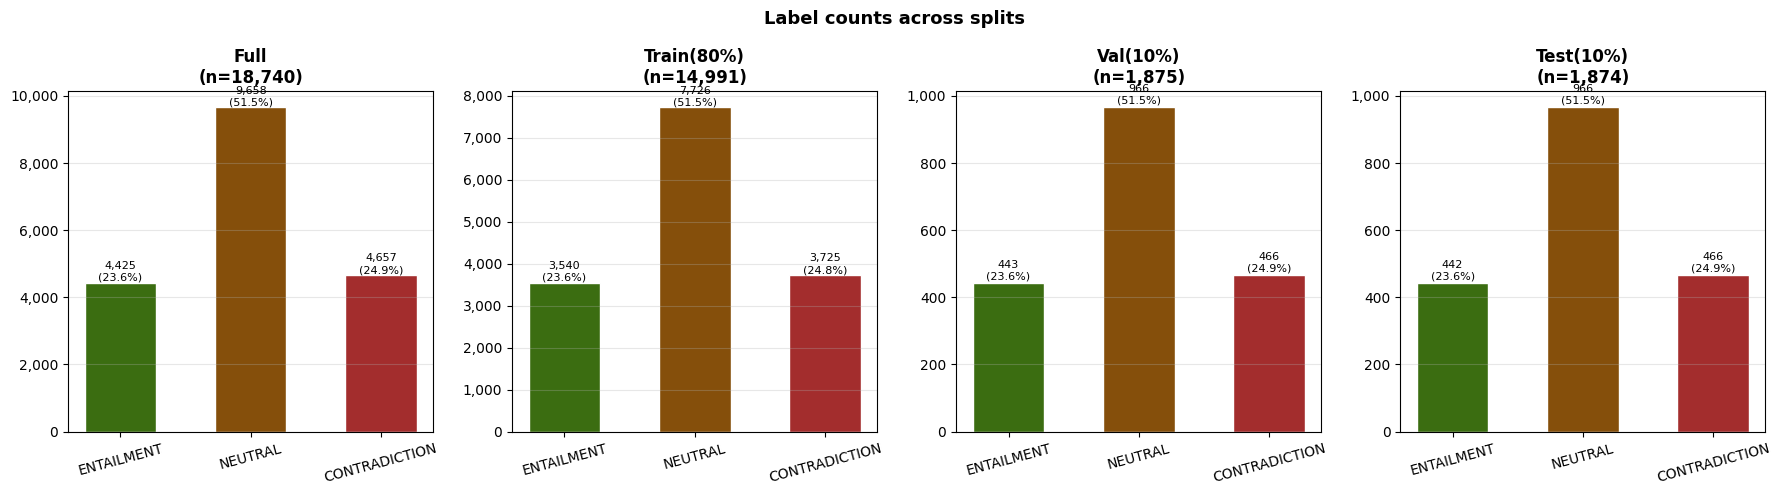

In [17]:
splits = {'Full':df_model,'Train(80%)':df_train,'Val(10%)':df_val,'Test(10%)':df_test}
split_colors = ['#374151','#185FA5','#854F0B','#3B6D11']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Label counts across splits', fontsize=13, fontweight='bold')
for ax, (sname, sdf) in zip(axes, splits.items()):
    counts = sdf['nli_label'].value_counts().reindex(NLI_ORDER).fillna(0)
    bars = ax.bar(counts.index, counts.values,
        color=[NLI_COLORS[l] for l in counts.index], edgecolor='white', width=0.55)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{int(val):,}\n({val/len(sdf):.1%})', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{sname}\n(n={len(sdf):,})', fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.grid(axis='y', alpha=0.3); ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'split_label_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df_train.to_csv(SPLITS_DIR / 'train.csv', index=False, encoding='utf-8-sig')
df_val.to_csv(  SPLITS_DIR / 'val.csv',   index=False, encoding='utf-8-sig')
df_test.to_csv( SPLITS_DIR / 'test.csv',  index=False, encoding='utf-8-sig')
print(f'Saved -> {SPLITS_DIR}/train.csv  ({len(df_train):,} rows)')
print(f'Saved -> {SPLITS_DIR}/val.csv    ({len(df_val):,} rows)')
print(f'Saved -> {SPLITS_DIR}/test.csv   ({len(df_test):,} rows)')

Saved -> ..\data\splits/train.csv  (14,991 rows)
Saved -> ..\data\splits/val.csv    (1,875 rows)
Saved -> ..\data\splits/test.csv   (1,874 rows)
